## Loading the dataset.

In [1]:
import sys
sys.path.append('..')

from pipeline import Pipeline

pipeline = Pipeline()
ratings_df = pipeline.load_data('../storage/u.data')  

Dataset loaded successfully.
Dataset Shape: (100000, 4)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None

First few rows:
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596


## Partitioning the data and visualizing rating distributions and timestamp distributions.

Distributions of the Original Data:


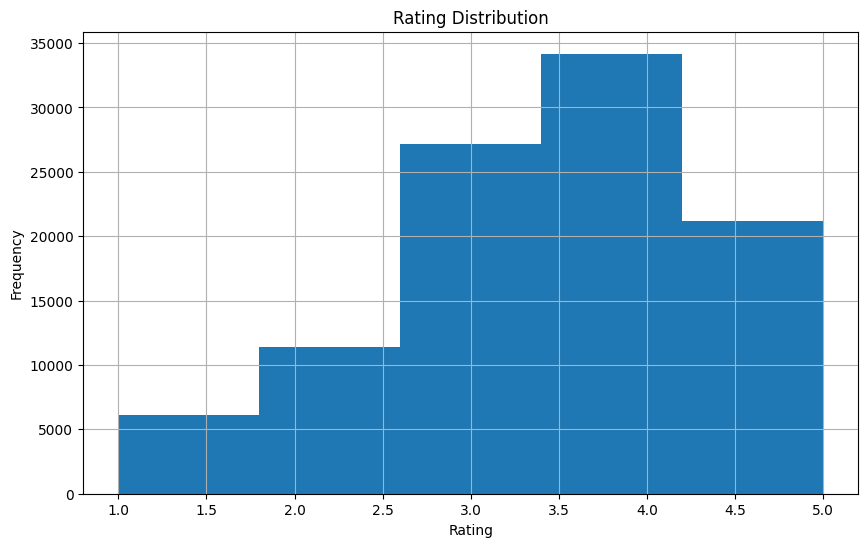

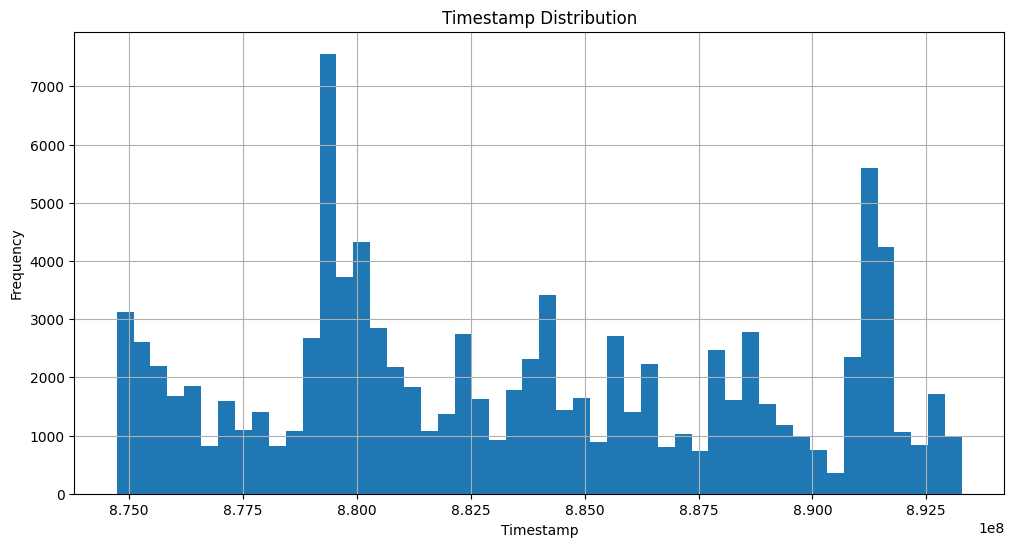

In [2]:
import matplotlib.pyplot as plt

def visualize_rating_distribution(df):
    plt.figure(figsize=(10, 6))
    df['rating'].hist(bins=5)
    plt.title('Rating Distribution')
    plt.xlabel('Rating')
    plt.ylabel('Frequency')
    plt.show()

def visualize_timestamp_distribution(df):
    plt.figure(figsize=(12, 6))
    df['timestamp'].hist(bins=50)
    plt.title('Timestamp Distribution')
    plt.xlabel('Timestamp')
    plt.ylabel('Frequency')
    plt.show()

print("Distributions of the Original Data:")
visualize_rating_distribution(ratings_df)
visualize_timestamp_distribution(ratings_df)

Distributions of the Temporal Partitioned Training Data:


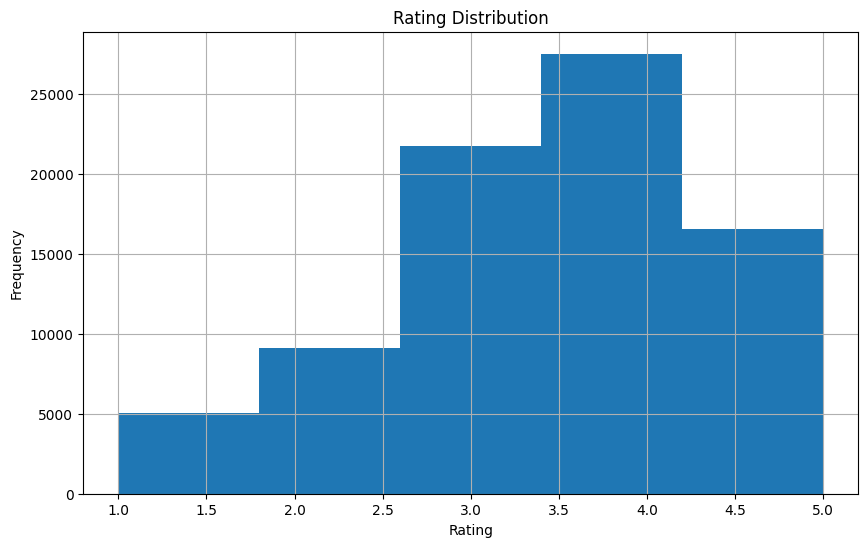

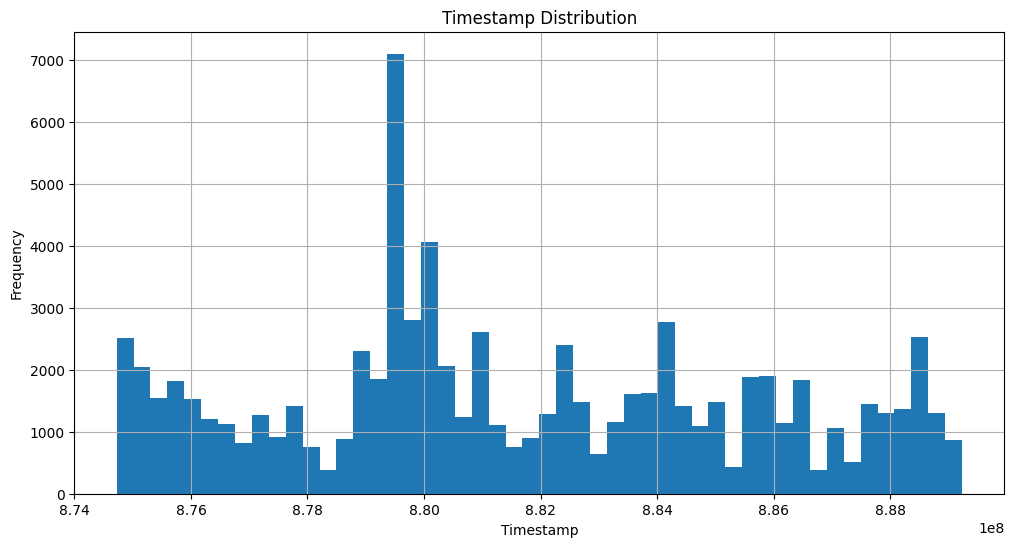

Distributions of the Temporal Partitioned Testing Data:


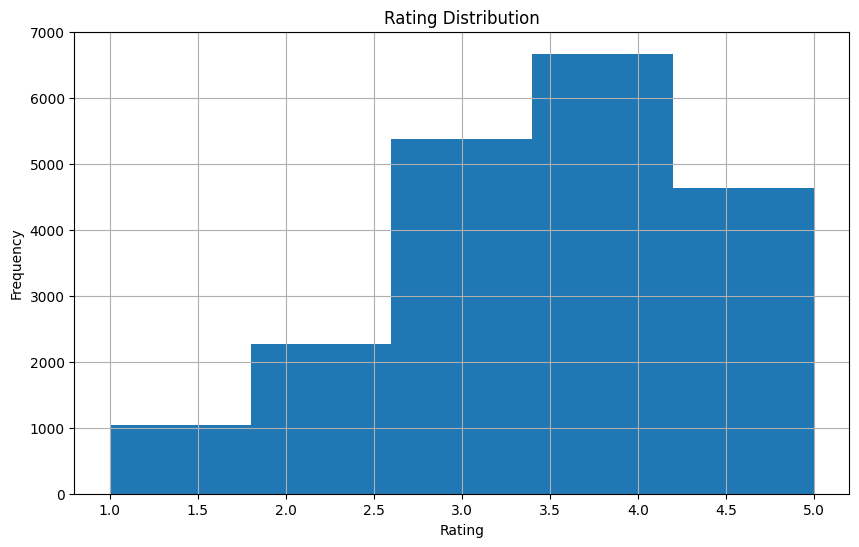

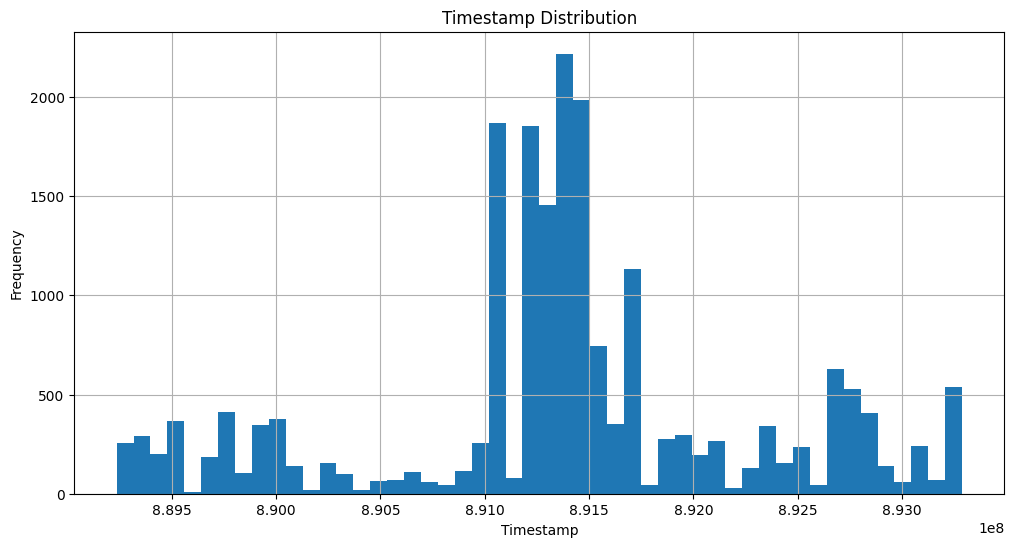

In [3]:
train_df, test_df = pipeline.partition_data(ratings_df, partition_type='temporal')

print("Distributions of the Temporal Partitioned Training Data:")
visualize_rating_distribution(train_df)
visualize_timestamp_distribution(train_df)

print("Distributions of the Temporal Partitioned Testing Data:")
visualize_rating_distribution(test_df)
visualize_timestamp_distribution(test_df)

Distributions of the User-stratified Partitioned Training Data:


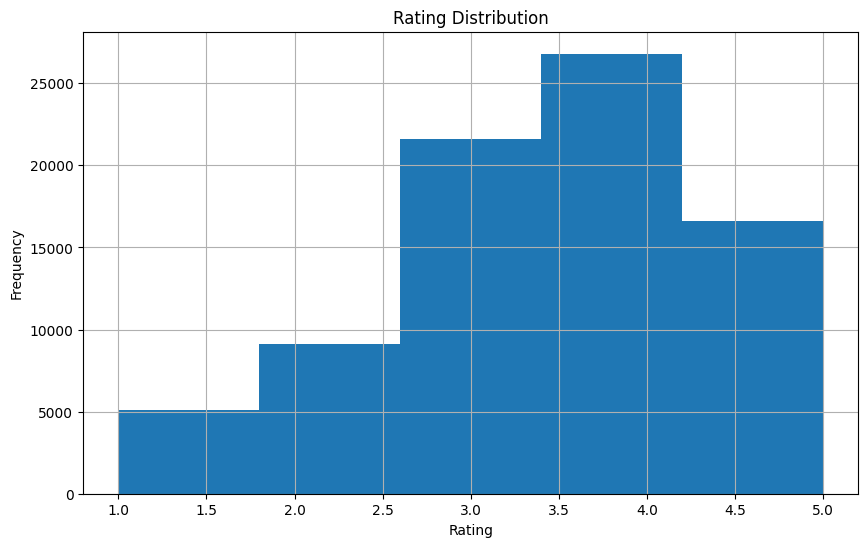

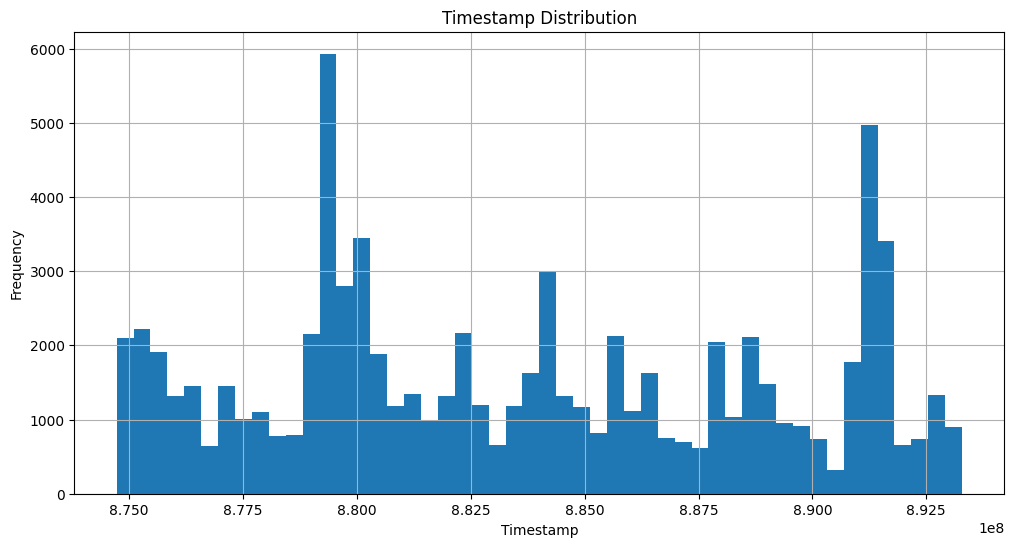

Distributions of the User-stratified Partitioned Testing Data:


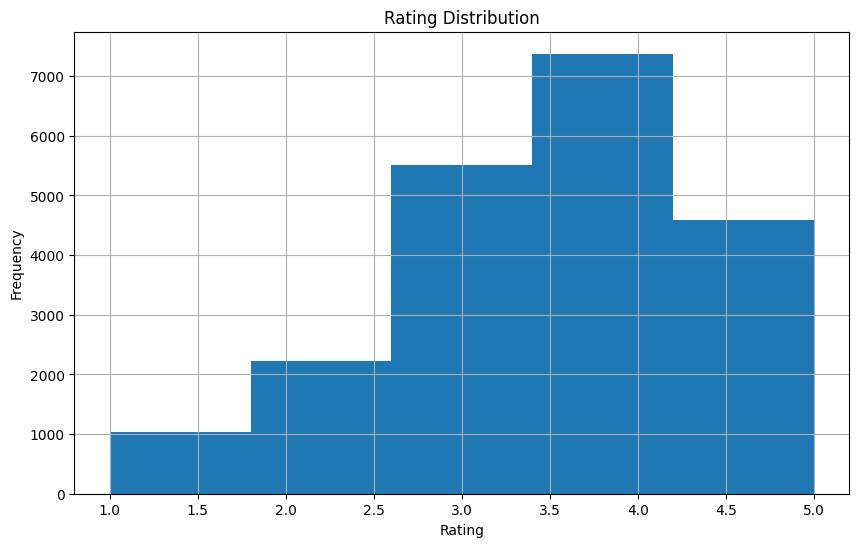

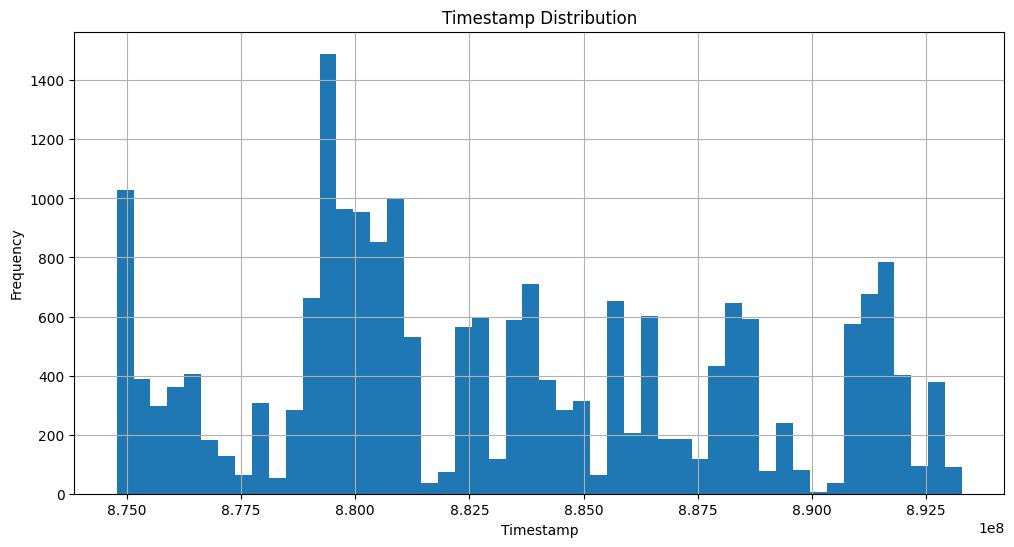

In [4]:
train_df, test_df = pipeline.partition_data(ratings_df, partition_type='stratified')

print("Distributions of the User-stratified Partitioned Training Data:")
visualize_rating_distribution(train_df)
visualize_timestamp_distribution(train_df)

print("Distributions of the User-stratified Partitioned Testing Data:")
visualize_rating_distribution(test_df)
visualize_timestamp_distribution(test_df)